In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd

pd.set_option('display.float_format', '{:.2f}'.format) 

# Simple regression models

We start by estimating two simple regression models, one OLS and one Logistic Regression.

Advertising dataset:


*   Features: Budget for advertisements on TV, radio, and newspaper
*   Target variable: sales



In [2]:
url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Regressions/datasets/advertising.csv"

print("Starting data migration from GitHub...")

try:
    df_ols = pd.read_csv(url, index_col=0)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [3]:
df_ols.head()

,TV,radio,newspaper,sales
1,230.10,37.80,69.20,22.10
2,44.50,39.30,45.10,10.40
3,17.20,45.90,69.30,9.30
4,151.50,41.30,58.50,18.50
5,180.80,10.80,58.40,12.90


Estimate an OLS regression model and interpret the results

In [4]:
model = smf.ols('sales ~ newspaper + radio + TV', data=df_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.58e-96
Time:                        17:31:45   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9389      0.312      9.422      0.0

Which variable has the strongest effect? Perform ex-post standardization of the coefficients and compare the effect strengths.

In [5]:
std_y = df_ols['sales'].std()

std_radio = df_ols['radio'].std()
std_TV = df_ols['TV'].std()

print(f'radio: {0.1885 * std_radio / std_y}')
print(f'TV: {0.0458 * std_TV / std_y}')

radio: 0.5363961337216626
TV: 0.7536476775034426


# Logistic models

In [6]:
url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Regressions/datasets/bank.csv"

print("Starting data migration from GitHub...")

try:
    df_bank = pd.read_csv(url)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [7]:
df_bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Get overview of the features and estimate a logistic regression model to explain the target variable "deposit".

In [8]:
df_bank['deposit'].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [9]:
df_bank['deposit_num'] = df_bank['deposit'].map({'yes':1 , 'no':0})

model = smf.logit('deposit_num ~ age + duration + balance + C(job) + C(housing)', data=df_bank).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.513064
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            deposit_num   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11146
Method:                           MLE   Df Model:                           15
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.2583
Time:                        17:31:45   Log-Likelihood:                -5726.8
converged:                       True   LL-Null:                       -7721.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -0.9214      0.122     -7.571      0.000      -1.160   

# Quadratic data

Consider the following code that generates the Japanese flag.

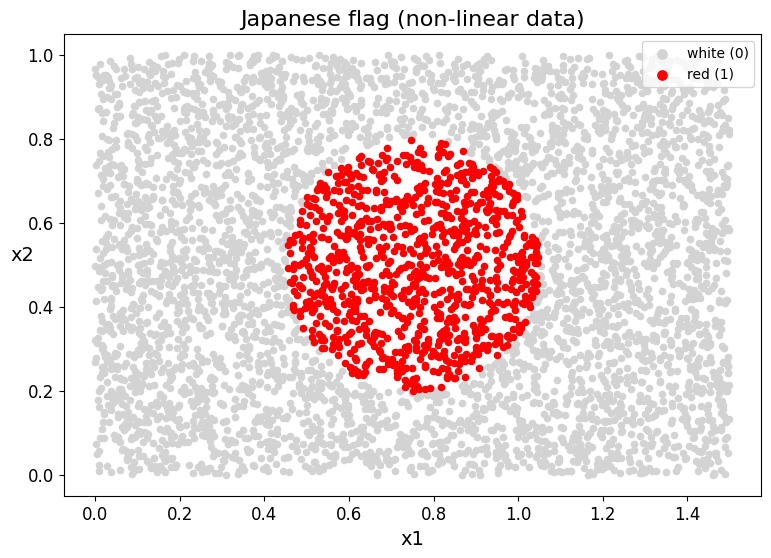

In [10]:
# size of the flag

height = 1
width = 1.5

# number of datapoints
N = 5000

# sample from uniform distribution
np.random.seed(42)

x1 = np.random.uniform(0, width, N)
x2 = np.random.uniform(0, height, N)

# circle in the middle

center_x, center_y = width / 2, height / 2
radius = 0.3

# calculate distances
distances = np.sqrt((x1 - center_x)**2 + (x2 - center_y)**2)
values = (distances <= radius).astype(int)


# create DataFrame
df_japan_flag = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'y': values
})

# Scatter plots
plt.figure(figsize=(9, 6))
plt.scatter(df_japan_flag[df_japan_flag['y'] == 0]['x1'],
            df_japan_flag[df_japan_flag['y'] == 0]['x2'],
            color='lightgray', s=20, label='white (0)')
plt.scatter(df_japan_flag[df_japan_flag['y'] == 1]['x1'],
            df_japan_flag[df_japan_flag['y'] == 1]['x2'],
            color='red', s=20, label='red (1)')

plt.title("Japanese flag (non-linear data)", fontsize=16)
plt.legend(loc='upper right', markerscale=1.5)
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", rotation=None, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


Create an OLS regression model that separates red from gray datapoints. If the predicted value is greater or equal to 0.5, the prediction is considered positive (1) and negative (0) otherwise.

In [11]:
df_japan_flag["x1sq"] = df_japan_flag["x1"] ** 2
df_japan_flag["x2sq"] = df_japan_flag["x2"] ** 2

model = smf.ols("y ~ x1 + x2 + x1sq + x2sq", data=df_japan_flag).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     785.2
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:31:46   Log-Likelihood:                -1222.4
No. Observations:                5000   AIC:                             2455.
Df Residuals:                    4995   BIC:                             2487.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.5785      0.018    -32.423      0.0

Test based on a few points

In [12]:
point_1 = [0.7, 0.5]
point_2 = [0.2, 0.2]
point_3 = [1.05, 0.5]

points = np.vstack((point_1, point_2, point_3))# NumPy 中用于 “垂直堆叠”（vertical stack）的函数
print(points.shape)

new_datapoints = pd.DataFrame({
    "x1": points[:,0],
    "x2": points[:,1],
    "x1sq": points[:,0] ** 2,
    "x2sq": points[:,1] ** 2
})

model.predict(new_datapoints)

(3, 2)


0   0.57
1   0.05
2   0.48
dtype: float64

Visualization of decision boundary

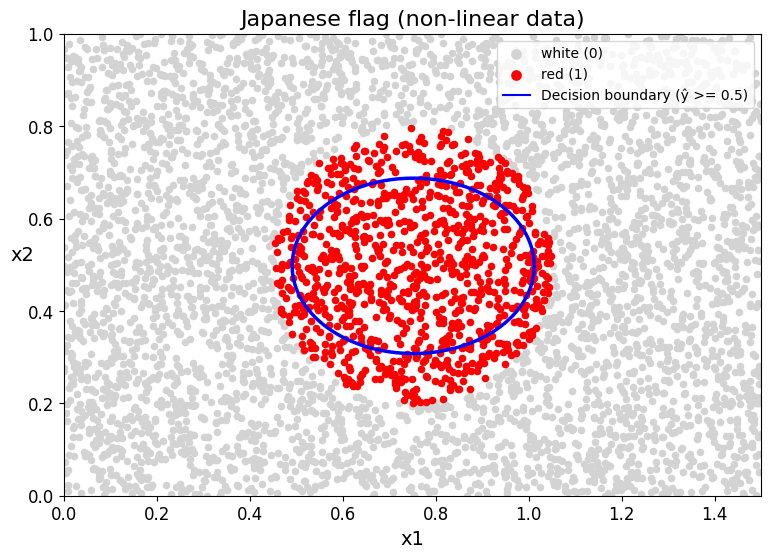

In [13]:
y_pred = model.fittedvalues
grid_points = 300
x1_grid, x2_grid = np.meshgrid(np.linspace(0, width, grid_points),
                               np.linspace(0, height, grid_points))

df_pred = pd.DataFrame({
    "x1": x1_grid.ravel(),
    "x2": x2_grid.ravel(),
})
df_pred["x1sq"] = df_pred["x1"] ** 2
df_pred["x2sq"] = df_pred["x2"] ** 2

# Vorhersage der Wahrscheinlichkeiten
df_pred["y_pred"] = model.predict(df_pred)

# Zeichne Entscheidungslinie (z.B. y_pred = 0.5)
plt.figure(figsize=(9, 6))
plt.contour(x1_grid, x2_grid, df_pred["y_pred"].values.reshape(x1_grid.shape),
            levels=[0.5], colors='blue', linewidths=2.5)


# Scatter plots
plt.scatter(df_japan_flag[df_japan_flag['y'] == 0]['x1'],
            df_japan_flag[df_japan_flag['y'] == 0]['x2'],
            color='lightgray', s=20, label='white (0)')
plt.scatter(df_japan_flag[df_japan_flag['y'] == 1]['x1'],
            df_japan_flag[df_japan_flag['y'] == 1]['x2'],
            color='red', s=20, label='red (1)')

# legend entry
plt.plot([], [], color="blue", label="Decision boundary (ŷ >= 0.5)")

plt.title("Japanese flag (non-linear data)", fontsize=16)
plt.legend(loc='upper right', markerscale=1.5)
plt.xlabel("x1", fontsize=14)
plt.ylabel("x2", rotation=None, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Heteroscedasticity Robust Standard Errors

Load the example dataset to illustrate the effect of robust standard errors

In [14]:
url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Regressions/datasets/standard_errors_example.csv"

print("Starting data migration from GitHub...")

try:
    df = pd.read_csv(url)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [15]:
print(len(df))
df.head()

200


,y,x
0,-1.46,3.75
1,7.76,9.51
2,7.22,7.32
3,-2.62,5.99
4,10.98,1.56


Estimate a OLS regression model y = x with spherical standard errors and assess t and p values of x. Does the hypothesis test of beta_x != 0 succeed with p < 0.05?

In [16]:
model = smf.ols("y ~ x", data=df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     4.018
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0464
Time:                        17:31:46   Log-Likelihood:                -685.13
No. Observations:                 200   AIC:                             1374.
Df Residuals:                     198   BIC:                             1381.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1694      1.018      2.131      0.0

Estimate a OLS regression model with robust standard errors (HC0). Compare the standard errors, t and p values with the naive OLS standard errors.

In [17]:
robust = smf.ols('y ~ x', data=df).fit(cov_type='HC0')

print(robust.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     3.687
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0563
Time:                        17:31:46   Log-Likelihood:                -685.13
No. Observations:                 200   AIC:                             1374.
Df Residuals:                     198   BIC:                             1381.
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1694      0.809      2.680      0.0

Estimate a OLS regression model with robust standard errors (HC1). Again, compare standard errors, t, and p-values.

In [18]:
robust = smf.ols('y ~ x', data=df).fit(cov_type='HC1')

print(robust.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     3.650
Date:                Thu, 23 Apr 2026   Prob (F-statistic):             0.0575
Time:                        17:31:46   Log-Likelihood:                -685.13
No. Observations:                 200   AIC:                             1374.
Df Residuals:                     198   BIC:                             1381.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1694      0.813      2.667      0.0

Visualize the regression line vs the data points.

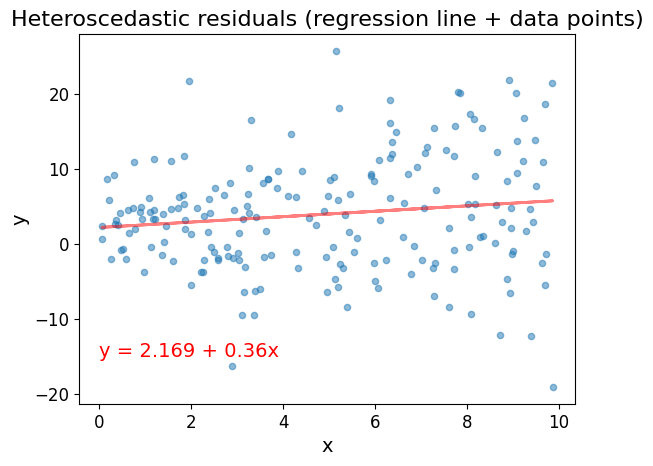

In [19]:
a, b = np.round(model.params, 3)
plt.plot(df["x"], model.fittedvalues, alpha=0.5, lw=2, c="red")
plt.scatter(df["x"], df["y"], alpha=0.5, s=20)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("Heteroscedastic residuals (regression line + data points)", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.text(0,-15,"y = "+str(a)+" + "+str(b)+"x", c="red", fontsize=14)
plt.show()

Visualize the residuals in another plot.

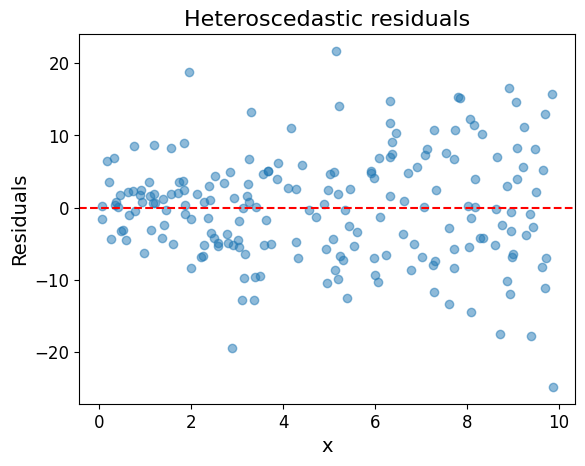

In [20]:
plt.scatter(df["x"], model.resid, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x", fontsize=14)
plt.ylabel("Residuals", fontsize=14)
plt.title("Heteroscedastic residuals", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Load Melbourne housing dataset

In [21]:
url = "https://raw.githubusercontent.com/isaakzyjiang/BAML-coursework/main/Regressions/datasets/melbourne_clean.csv"

print("Starting data migration from GitHub...")

try:
    df = pd.read_csv(url)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error: {e}")

Starting data migration from GitHub...
Data loaded successfully


In [22]:
df = df[df['Type'] != 'unknown']

df['BuildingArea'] = df['BuildingArea_winsorized']
df['Landsize'] = df['Landsize_winsorized']

df.head()

,Price,Suburb,Rooms,Type,Method,Date,Postcode,Bedrooms,Bathroom,Car,...,CouncilArea,Latitude,Longitude,Regionname,Propertycount,Rooms_winsorized,Landsize_winsorized,BuildingArea_winsorized,Car_Missing,distance_cbd_km
0,1480000.00,Abbotsford,2,House,S,3/12/2016,3067.00,2.00,1.00,1.00,...,Yarra City Council,-37.80,145.00,Northern Metropolitan,4019.00,2,202.00,NaN,False,4.25
1,1035000.00,Abbotsford,2,House,S,4/02/2016,3067.00,2.00,1.00,0.00,...,Yarra City Council,-37.81,144.99,Northern Metropolitan,4019.00,2,156.00,79.00,False,3.49
2,1465000.00,Abbotsford,3,House,SP,4/03/2017,3067.00,3.00,2.00,0.00,...,Yarra City Council,-37.81,144.99,Northern Metropolitan,4019.00,3,134.00,150.00,False,3.58
3,850000.00,Abbotsford,3,House,PI,4/03/2017,3067.00,3.00,2.00,1.00,...,Yarra City Council,-37.80,145.00,Northern Metropolitan,4019.00,3,94.00,NaN,False,4.20
4,941000.00,Abbotsford,2,House,S,7/05/2016,3067.00,2.00,1.00,0.00,...,Yarra City Council,-37.80,145.00,Northern Metropolitan,4019.00,2,181.00,NaN,False,3.77


Estimate a regression model that explains the Price based on BuildingArea, Bedrooms, DistanceCBD, Landsize and the house type

In [23]:
model = smf.ols('Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type)', data=df, missing='drop').fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     1004.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:51:28   Log-Likelihood:            -1.1003e+05
No. Observations:                7585   AIC:                         2.201e+05
Df Residuals:                    7577   BIC:                         2.201e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

Estimate the same model again with robust standard errors HC0 and HC1

In [24]:
model = smf.ols('Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type)', data=df, missing='drop').fit(cov_type='HC0')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     710.3
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:52:35   Log-Likelihood:            -1.1003e+05
No. Observations:                7585   AIC:                         2.201e+05
Df Residuals:                    7577   BIC:                         2.201e+05
Df Model:                           7                                         
Covariance Type:                  HC0                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [25]:
model = smf.ols('Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type)', data=df, missing='drop').fit(cov_type='HC1')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.481
Method:                 Least Squares   F-statistic:                     709.5
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:52:54   Log-Likelihood:            -1.1003e+05
No. Observations:                7585   AIC:                         2.201e+05
Df Residuals:                    7577   BIC:                         2.201e+05
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

# Clustered Standard Errors

We expect that the standard errors in Melbourne housing are clustered according to the Suburb.

Print the value counts of the suburb column.

In [28]:
df['Suburb'].value_counts().nlargest(50)

Suburb
Reservoir            663
Bentleigh East       440
Richmond             393
Preston              362
Brunswick            343
Essendon             336
Northcote            310
Glenroy              304
South Yarra          295
Glen Iris            292
Brighton             289
Kew                  286
Coburg               280
Hawthorn             278
Pascoe Vale          273
Balwyn North         270
St Kilda             266
Camberwell           257
Port Melbourne       242
Bentleigh            239
Thornbury            238
Brighton East        230
Yarraville           227
Moonee Ponds         212
Balwyn               203
Carnegie             203
Footscray            201
Hampton              201
Ascot Vale           199
Malvern East         198
Prahran              192
Newport              191
Keilor East          189
Doncaster            186
Surrey Hills         185
Brunswick West       184
Craigieburn          184
Hawthorn East        179
Maribyrnong          178
Elwood            

Estimate a OLS regression models that explains Price based on BuildingArea, Bedrooms, DistanceCBD, Landsize, Type and DistanceCBD x Type. Evaluate HC0 and HC1 and assess the standard errors.

In [29]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df, missing="drop").fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     729.8
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:05:39   Log-Likelihood:            -1.0996e+05
No. Observations:                7585   AIC:                         2.199e+05
Df Residuals:                    7574   BIC:                         2.200e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [30]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df, missing="drop").fit(cov_type='HC0')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                 1.797e+04
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:06:03   Log-Likelihood:            -1.0996e+05
No. Observations:                7585   AIC:                         2.199e+05
Df Residuals:                    7574   BIC:                         2.200e+05
Df Model:                          10                                         
Covariance Type:                  HC0                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/Users/isaakjiang/Desktop/Isaak/library/Python Envrionments/260421_Claude/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [31]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df, missing="drop").fit(cov_type='HC1')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                 1.794e+04
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:06:38   Log-Likelihood:            -1.0996e+05
No. Observations:                7585   AIC:                         2.199e+05
Df Residuals:                    7574   BIC:                         2.200e+05
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/Users/isaakjiang/Desktop/Isaak/library/Python Envrionments/260421_Claude/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


Now, estimate the same regression model again and then calculate the clustered standard errors according to the Suburb. Compare the standard errors, t-values, and p-values. In addition, calculate the standard errors with and without correction to see the effects of the correction.

In [ ]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df, missing='drop').fit()

used_rows = model.model.data.row_labels
clustered = model.get_robustcov_results(cov_type='cluster', groups=df.loc[used_rows, 'Suburb'], use_correction=False)
print(clustered.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     4216.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:18:43   Log-Likelihood:            -1.0996e+05
No. Observations:                7585   AIC:                         2.199e+05
Df Residuals:                    7574   BIC:                         2.200e+05
Df Model:                          10                                         
Covariance Type:              cluster                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/Users/isaakjiang/Desktop/Isaak/library/Python Envrionments/260421_Claude/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


In [34]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df, missing='drop').fit()

used_rows = model.model.data.row_labels
clustered = model.get_robustcov_results(cov_type='cluster', groups=df.loc[used_rows, 'Suburb'], use_correction=True)
print(clustered.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.490
Method:                 Least Squares   F-statistic:                     4197.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:19:20   Log-Likelihood:            -1.0996e+05
No. Observations:                7585   AIC:                         2.199e+05
Df Residuals:                    7574   BIC:                         2.200e+05
Df Model:                          10                                         
Covariance Type:              cluster                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/Users/isaakjiang/Desktop/Isaak/library/Python Envrionments/260421_Claude/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 10, but rank is 9
  warnings.warn('covariance of constraints does not have full '


The effect of the correction is very small since the number of clusters is very high.

Let us look at a reduced set with fewer clusters. Select the top-10 clusters with most real estate transactions.

In [35]:
df['Suburb'].value_counts().nlargest(20)

Suburb
Reservoir         663
Bentleigh East    440
Richmond          393
Preston           362
Brunswick         343
Essendon          336
Northcote         310
Glenroy           304
South Yarra       295
Glen Iris         292
Brighton          289
Kew               286
Coburg            280
Hawthorn          278
Pascoe Vale       273
Balwyn North      270
St Kilda          266
Camberwell        257
Port Melbourne    242
Bentleigh         239
Name: count, dtype: int64

In [41]:
top_suburbs = df['Suburb'].value_counts().nlargest(10).index

df_top10 = df[df['Suburb'].isin(top_suburbs)]

Reestimate the regression models with and without clustered SE. Compare the standard errors, t, and p-values of the interaction terms.

In [42]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df_top10, missing='drop').fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     152.5
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          4.22e-172
Time:                        21:27:43   Log-Likelihood:                -15801.
No. Observations:                1103   AIC:                         3.162e+04
Df Residuals:                    1094   BIC:                         3.166e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [43]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df_top10, missing='drop').fit()

used_rows = model.model.data.row_labels

clustered = model.get_robustcov_results(cov_type="cluster", groups=df_top10.loc[used_rows, "Suburb"], use_correction=False)
print(clustered.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     90.60
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.09e-07
Time:                        21:28:25   Log-Likelihood:                -15801.
No. Observations:                1103   AIC:                         3.162e+04
Df Residuals:                    1094   BIC:                         3.166e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

With correction

In [44]:
model = smf.ols("Price ~ BuildingArea + Bedrooms + distance_cbd_km + Landsize + C(Type) + distance_cbd_km * C(Type)", data=df_top10, missing='drop').fit()

used_rows = model.model.data.row_labels

clustered = model.get_robustcov_results(cov_type="cluster", groups=df_top10.loc[used_rows, "Suburb"], use_correction=True)
print(clustered.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     80.95
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.79e-07
Time:                        21:30:02   Log-Likelihood:                -15801.
No. Observations:                1103   AIC:                         3.162e+04
Df Residuals:                    1094   BIC:                         3.166e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

# Regularized Regression Models

In [46]:
from sklearn.linear_model import LassoCV
import sklearn.datasets
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

We will now use the LASSO regression for feature selection in a high-dimensional dataset with F >> N.

The Leukemia dataset is a classic high-dimensional gene expression dataset used in biomedical and machine learning research. It was originally published in the paper: Golub, T. R., Slonim, D. K., Tamayo, P., Huard, C., Gaasenbeek, M., Mesirov, J. P., ... & Lander, E. S. (1999). Molecular classification of cancer: class discovery and class prediction by gene expression monitoring. science, 286(5439), 531-537.



*   Samples (observations): 72
*   Features (genes): 7,129 gene expression levels
*   Target: Type of leukemia (binary classification):

    ALL (Acute Lymphoblastic Leukemia)

    AML (Acute Myeloid Leukemia)

In [47]:
leukemia = sklearn.datasets.fetch_openml("leukemia", version=1)
X = leukemia.data
y = leukemia.target

y_binary = y.map({'ALL': 0, 'AML': 1}).astype(int).to_numpy()

print(X.shape)
print(np.mean(y_binary))

(72, 7129)
0.3472222222222222


Feature selection has to be performed based on training data only!

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

In [49]:
lasso = LassoCV(cv=5).fit(X_train, y_train)

print("Optimal alpha", lasso.alpha_)

selected = np.sum(lasso.coef_ != 0)
print("relevant: ", selected)

Optimal alpha 54.71255522117251
relevant:  35


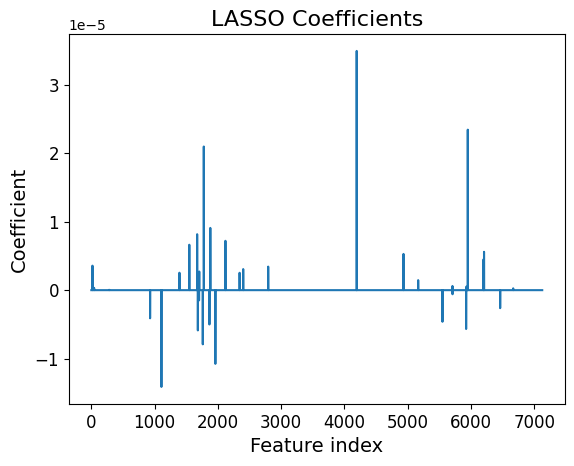

In [54]:
plt.plot(lasso.coef_)
plt.title("LASSO Coefficients", fontsize=16)
plt.xlabel("Feature index", fontsize=14)
plt.ylabel("Coefficient", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()